In [1]:

import importlib
import new_import
importlib.reload(new_import)

from new_import import *

In [2]:
cluster, client = notebook_utils.initialize_dask(use_gateway=True, workers=(1,10))
# Khai báo 1 Datacube là dc
dc = datacube.Datacube()
client

Starting new cluster.


Connection method: Cluster object,Cluster type: dask_gateway.GatewayCluster
Dashboard: https://hub.asia.easi-eo.solutions/services/dask-gateway/clusters/easihub.b6811833ff2d49e0b4bf19bcd65ee123/status,


2025-02-14 01:02:35,415 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client


In [3]:
date_range = ('2023-09-01', '2023-10-01')
longtitude_range = (105.5, 106.4)
latitude_range = (9.2, 10.0) 

coordinates = (longtitude_range, latitude_range)

In [4]:
dsvh, dsvv = load_data_sen1(dc, date_range, coordinates)
data_sen2 = load_data_sen2(dc, date_range, coordinates)
notebook_utils.heading(notebook_utils.xarray_object_size(data_sen2))
display(data_sen2)

<xarray.Dataset> Size: 2GB
Dimensions:      (time: 3, y: 8874, x: 9902)
Coordinates:
  * time         (time) datetime64[ns] 24B 2023-09-01T22:46:18.500000 ... 202...
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
    spatial_ref  int32 4B 32648
Data variables:
    vv           (time, y, x) float32 1GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    vh           (time, y, x) float32 1GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
Attributes:
    crs:           EPSG:32648
    grid_mapping:  spatial_ref

No datasets require offset correction
The valid_data_mask and scale (no offset) have been applied to the reflectance bands


<xarray.Dataset> Size: 9GB
Dimensions:      (time: 12, y: 8874, x: 9902)
Coordinates:
  * time         (time) datetime64[ns] 96B 2023-09-02T03:35:16.627000 ... 202...
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
    spatial_ref  int32 4B 32648
Data variables:
    red          (time, y, x) float32 4GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    nir          (time, y, x) float32 4GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    scl          (time, y, x) uint8 1GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
Attributes:
    crs:           EPSG:32648
    grid_mapping:  spatial_ref

In [5]:
average_vh = calculate_average(dsvh, time_pattern='1M')
progress(average_vh)

/env/lib/python3.12/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


VBox()

In [6]:
average_vv = calculate_average(dsvv, time_pattern='1M')
progress(average_vv)

/env/lib/python3.12/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


VBox()

In [7]:
result = mask_cloud(data_sen2)
progress(result)

{'0': 'no data',
 '1': 'saturated or defective',
 '2': 'dark area pixels',
 '3': 'cloud shadows',
 '4': 'vegetation',
 '5': 'bare soils',
 '6': 'water',
 '7': 'unclassified',
 '8': 'cloud medium probability',
 '9': 'cloud high probability',
 '10': 'thin cirrus',
 '11': 'snow or ice'}

VBox()

In [8]:
dsNDVI = calculate_indices(result, index='NDVI', satellite_mission='s2')
ndvi = dsNDVI["NDVI"]

In [9]:
average_ndvi = calculate_average(ndvi,time_pattern="1M")
progress(average_ndvi)

/env/lib/python3.12/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


VBox()

In [10]:
%%time
average_vh = average_vh.compute()
average_vv = average_vv.compute()
average_ndvi = average_ndvi.compute()

CPU times: user 1.12 s, sys: 1.13 s, total: 2.24 s
Wall time: 4min 40s


#####################################CREATE DATASET#######################################################

In [11]:
input_path = "./input/masks/ST_lua2v.tif"
data = rioxarray.open_rasterio(input_path)
data

<xarray.DataArray (band: 1, y: 6727, x: 7151)> Size: 48MB
[48104777 values with dtype=uint8]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 57kB 5.597e+05 5.598e+05 ... 6.312e+05 6.312e+05
  * y            (y) float64 54kB 1.097e+06 1.097e+06 ... 1.03e+06 1.03e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:       Area
    RepresentationType:  THEMATIC
    _FillValue:          255
    scale_factor:        1.0
    add_offset:          0.0

In [12]:
# Convert to numpy array (assuming a single-band raster)
data_np = data.values.squeeze()

In [13]:
import xarray as xr
import numpy as np

# Assuming 'data' is your xarray.DataArray
mask = data != 255  # Boolean mask where values are not 255

# Stack x and y dimensions into a single index
data_stacked = data.stack(points=("y", "x"))

# Apply the mask and drop NaN values
filtered = data_stacked.where(data_stacked != 255, drop=True)

# Extract x and y coordinates
x_indices = filtered.coords["x"].values
y_indices = filtered.coords["y"].values

# Stack into a (N, 2) NumPy array
xy_valid = np.column_stack((x_indices, y_indices))

print(xy_valid)  # Print or use the filtered coordinates


[[ 598782.754  1097385.3978]
 [ 610132.754  1087655.3978]
 [ 607522.754  1087455.3978]
 ...
 [ 608912.754  1030175.3978]
 [ 608922.754  1030175.3978]
 [ 608132.754  1030125.3978]]


In [ ]:
ndvi = []
vh = []
vv = []

def extract_data(index):
    ndvi_data = average_ndvi.sel(x=index[0], y=index[1], method='nearest').values
    vh_data = average_vh.sel(x=index[0], y=index[1], method='nearest').values
    vv_data = average_vv.sel(x=index[0], y=index[1], method='nearest').values
    return ndvi_data, vh_data, vv_data

# Process data sequentially
i = 0
for index in xy_valid:
    ndvi_data, vh_data, vv_data = extract_data(index)
    ndvi.append(ndvi_data)
    vh.append(vh_data)
    vv.append(vv_data)


In [ ]:
ndvi = np.concatenate(ndvi)
vh = np.concatenate(vh)
vv = np.concatenate(vv)

In [ ]:
nan_indices = ~np.isnan(ndvi)
print(nan_indices)
ndvi_nan = ndvi[nan_indices]
vh_nan = vh[nan_indices]
vv_nan = vv[nan_indices]

In [ ]:
ndvi_nan = ndvi_nan[:2000000]
vh_nan = vh_nan[:2000000]
vv_nan = vv_nan[:2000000]

In [ ]:
ndvi_nan.shape

In [ ]:
features = np.stack([vh_nan, vv_nan], axis=1)
features.shape

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(features, ndvi_nan, test_size=0.2, random_state=42)

In [ ]:
from sklearn.neural_network import MLPRegressor
regressors = {
        'random_forest': RandomForestRegressor(random_state=42),
        'svr': SVR(),
        'gradient_boosting': GradientBoostingRegressor(random_state=42),
        'linear_regression': LinearRegression(),
        'knn': KNeighborsRegressor(),
        'mlp': MLPRegressor(random_state=42, max_iter=1000)
    }
param_grids_regressor = {
    'random_forest': {
        'n_estimators': [500],
        'max_depth': [ 10],
    },
    'svr': {
        'kernel': ['poly', 'linear'],
        'C': [0.1, 1, 10],
        'degree': [2, 3],  # For poly kernel
    },
    'gradient_boosting': {
        'n_estimators': [300],
        'learning_rate': [ 0.05],
        'max_depth': [3, 4, 5],
    },
    'linear_regression': {
        # 'alpha': [0.01, 0.1, 1, 10, 100],  # Regularization strength
        # 'fit_intercept': [True, False],
        # 'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg'],
    },
    'knn': {
        'n_neighbors': [3, 5, 7, 10, 20, 30, 50],
        'weights': ['uniform', 'distance'],
        'p': [1, 2, 3],
    },
    'mlp' : {
        'hidden_layer_sizes': [(64, 32), (128, 64), (64, 32, 16),  (128, 64, 32)],
        'activation': ['relu', 'tanh'],
        'solver': ['adam', 'sgd'],
        'learning_rate_init': [0.001, 0.01, 0.1]
    }
}

In [ ]:
%%time
best_model, best_params, best_score_r2, best_score_mae, cv_results = find_best_regression(
    X_train, y_train, regressors['random_forest'], param_grids_regressor['random_forest']
)

In [ ]:
folder_path = 'output/regressors/mask'
file_path = os.path.join(folder_path, 'rf_lua2v2.pkl')
joblib.dump(best_model, file_path)

In [ ]:
y_pred = best_model.predict(X_test)
# Calculate R² score
r2 = r2_score(y_test, y_pred)
# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"R² Score: {r2}")
print(f"Mean Squared Error: {mse}")
print("Mean Absolute Error:", abs(mae))

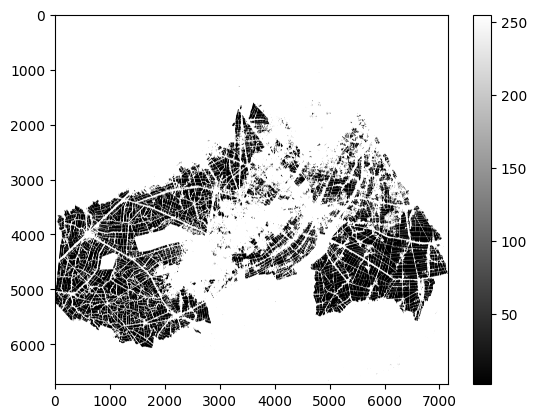

In [13]:
import matplotlib.pyplot as plt

plt.imshow(mask[0], cmap='gray')  # Show the first band
plt.colorbar()
plt.show()